## Threshold Testing and Evaluation

This notebook evaluates all 30 model-configuration combinations using cosine similarity and threshold-based binary classification. The evaluation is reported in two parts.

Part 1 runs the full-dataset sweep on all 154 pairs. The threshold that maximizes F1 is selected on the same 154 pairs on which F1 is then reported, which means Part 1 numbers are in-sample optimistic estimates and are presented as such. Bootstrap 95 percent confidence intervals are attached to every F1 value so that the size of the uncertainty around each estimate is visible.

Part 2 runs stratified 5-fold cross-validation. The threshold is selected on the training folds only and F1 is reported on the held-out folds. Results are summarized as mean and standard deviation of F1 across the five folds, which gives a more honest estimate of held-out performance than any single split. McNemar's test is then used to check whether the best-model comparisons are statistically meaningful given the dataset size.

### Imports and Setup

In [1]:
import sys
import random
import warnings
from pathlib import Path
from importlib.metadata import version

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    precision_score, recall_score, f1_score, accuracy_score,
    roc_auc_score, roc_curve, confusion_matrix,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from scipy.stats import binomtest

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

warnings.filterwarnings("ignore", category=FutureWarning)

print(f"Python : {sys.version.split()[0]}")
print(f"numpy  : {np.__version__}")
print(f"pandas : {pd.__version__}")
print(f"sklearn: {version('scikit-learn')}")
print(f"scipy  : {version('scipy')}")

Python : 3.10.20
numpy  : 2.2.6
pandas : 2.3.3
sklearn: 1.7.2
scipy  : 1.15.3


### Project Paths

All paths are derived from the notebook's working directory using `pathlib`, so the pipeline runs unchanged on any machine. The notebook assumes it is executed either from the project root or from a `notebooks/` subdirectory.

In [2]:
_cwd = Path.cwd()
PROJECT_ROOT = _cwd.parent if _cwd.name == "notebooks" else _cwd

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
EMBEDDINGS_DIR = DATA_DIR / "embeddings" / "ict"
THRESHOLD_DIR = DATA_DIR / "results" / "threshold_sweeps"
SUMMARY_DIR = DATA_DIR / "results" / "summary_tables"
FIGURES_DIR = PROJECT_ROOT / "figures" / "main"

THRESHOLD_DIR.mkdir(parents=True, exist_ok=True)
SUMMARY_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root     : {PROJECT_ROOT}")
print(f"Embeddings in    : {EMBEDDINGS_DIR}")
print(f"Threshold sweeps : {THRESHOLD_DIR}")
print(f"Summary tables   : {SUMMARY_DIR}")
print(f"Figures out      : {FIGURES_DIR}")

Project root     : c:\Users\madee\OneDrive\Desktop\thesis
Embeddings in    : c:\Users\madee\OneDrive\Desktop\thesis\data\embeddings\ict
Threshold sweeps : c:\Users\madee\OneDrive\Desktop\thesis\data\results\threshold_sweeps
Summary tables   : c:\Users\madee\OneDrive\Desktop\thesis\data\results\summary_tables
Figures out      : c:\Users\madee\OneDrive\Desktop\thesis\figures\main


### Loading the Dataset and Labels

The preprocessed dataset produced by Notebook 1 is loaded here. Only the similarity labels are needed for evaluation; the configuration text columns have already been consumed by Notebook 2 to produce the embedding files.

In [3]:
data_path = PROCESSED_DIR / "dataset_preprocessed.csv"
df = pd.read_csv(data_path)
labels = df['similarity_label'].values

print(f"Dataset loaded : {df.shape}")
print(f"Label counts   : {dict(zip(*np.unique(labels, return_counts=True)))}")

Dataset loaded : (154, 33)
Label counts   : {np.int64(0): np.int64(77), np.int64(1): np.int64(77)}


### Embedding File Sanity Check

All 60 embedding files were verified in Notebook 2 at save time. Because the files are reloaded here from disk, the three essential properties, expected shape `(154, 768)`, unit L2 norm within tolerance 1e-5, and absence of NaN values, are re-verified as assertions before any similarity scores are computed. Any issue halts execution immediately rather than propagating into the evaluation results.

In [4]:
model_keys = ['mpnet', 'stsb', 'e5', 'labse', 'finbert']
configs = [1, 2, 3, 4, 5, 6]
languages = ['fi', 'en']
expected_shape = (len(df), 768)

for model_key in model_keys:
    for config_num in configs:
        for lang in languages:
            fp = EMBEDDINGS_DIR / f'{model_key}_config{config_num}_{lang}.npy'
            assert fp.exists(), f"Missing file: {fp}"
            emb = np.load(fp)
            assert emb.shape == expected_shape, f"Shape {emb.shape} in {fp.name}"
            assert not np.isnan(emb).any(), f"NaN values in {fp.name}"
            norms = np.linalg.norm(emb, axis=1)
            assert np.allclose(norms, 1.0, atol=1e-5), (
                f"L2 norm drift in {fp.name}: range [{norms.min():.6f}, {norms.max():.6f}]"
            )

print(f"All 60 embedding files verified: shape {expected_shape}, unit L2 norm, no NaN.")

All 60 embedding files verified: shape (154, 768), unit L2 norm, no NaN.


### Evaluation Method

For each model-configuration combination, cosine similarity is computed row-wise between Finnish and English embeddings. Because all embeddings were L2 normalized in Notebook 2, cosine similarity reduces to a simple elementwise product followed by a row-wise sum, which is the most efficient formulation.

A threshold sweep tests 101 values from 0.00 to 1.00 in steps of 0.01. At each threshold, pairs with a similarity score above the threshold are classified as equivalent. Precision, recall, F1, and accuracy are recorded at every step. AUC is computed directly from the raw similarity scores and is independent of any threshold, making it a useful complement to threshold-based metrics when assessing discriminative power.

Uncertainty is quantified through a percentile bootstrap with 1000 resamples. For each bootstrap iteration, pairs are resampled with replacement at the original sample size, F1 is recomputed at a fixed threshold, and the 2.5th and 97.5th percentiles across iterations give the 95 percent confidence interval. The bootstrap uses a fixed seed for reproducibility.

In [5]:
thresholds = np.round(np.arange(0.00, 1.01, 0.01), 2)
N_BOOTSTRAP = 1000

config_names = {
    1: 'Outcomes (Raw)',
    2: 'Outcomes + Contents (Raw)',
    3: 'Outcomes + Contents + Assessment (Raw)',
    4: 'Outcomes (Lemmatized)',
    5: 'Outcomes + Contents (Lemmatized)',
    6: 'Outcomes + Contents + Assessment (Lemmatized)',
}

def cosine_row(fi_emb, en_emb):
    """Row-wise cosine similarity between pairs of unit-norm vectors."""
    return np.sum(fi_emb * en_emb, axis=1)

def threshold_sweep(similarity_scores, y_true, thresholds):
    """Sweep thresholds and compute P, R, F1, accuracy at each."""
    records = []
    for t in thresholds:
        preds = (similarity_scores >= t).astype(int)
        records.append({
            'threshold': t,
            'precision': precision_score(y_true, preds, zero_division=0),
            'recall'   : recall_score(y_true, preds, zero_division=0),
            'f1'       : f1_score(y_true, preds, zero_division=0),
            'accuracy' : accuracy_score(y_true, preds),
        })
    return pd.DataFrame(records)

def best_threshold(sweep_df):
    """Return threshold, F1 at the centre of the plateau of maximum F1.
    
    When multiple thresholds share the same F1, choosing the median of the
    plateau is more stable under small data perturbations than choosing the
    first argmax.
    """
    max_f1 = sweep_df['f1'].max()
    plateau = sweep_df.loc[sweep_df['f1'] == max_f1, 'threshold'].values
    return float(np.median(plateau)), float(max_f1)

def bootstrap_f1(similarity_scores, y_true, threshold, n_iter=N_BOOTSTRAP, seed=SEED):
    """Percentile bootstrap 95 percent CI for F1 at a fixed threshold."""
    rng = np.random.default_rng(seed)
    n = len(y_true)
    f1s = []
    for _ in range(n_iter):
        idx = rng.integers(0, n, n)
        yt = y_true[idx]
        if len(np.unique(yt)) < 2:
            continue
        preds = (similarity_scores[idx] >= threshold).astype(int)
        f1s.append(f1_score(yt, preds, zero_division=0))
    f1s = np.array(f1s)
    return float(f1s.mean()), float(np.percentile(f1s, 2.5)), float(np.percentile(f1s, 97.5))

def mcnemar_exact(preds_a, preds_b, y_true):
    """Exact binomial McNemar's test on paired classifier predictions.
    
    Returns (p_value, n_a_only_correct, n_b_only_correct). The p-value tests
    the null hypothesis that the two classifiers have the same error rate.
    """
    a_ok = (preds_a == y_true)
    b_ok = (preds_b == y_true)
    n10 = int(np.sum(a_ok & ~b_ok))
    n01 = int(np.sum(~a_ok & b_ok))
    n_disc = n10 + n01
    if n_disc == 0:
        return 1.0, n10, n01
    k = min(n10, n01)
    p = binomtest(k, n_disc, p=0.5, alternative='two-sided').pvalue
    return float(p), n10, n01

print(f"Thresholds          : {len(thresholds)} values from {thresholds[0]} to {thresholds[-1]}")
print(f"Bootstrap iterations: {N_BOOTSTRAP}")

Thresholds          : 101 values from 0.0 to 1.0
Bootstrap iterations: 1000


## Part 1: Full-Dataset Evaluation (In-Sample Estimates)

All 30 model-configuration combinations are evaluated here. For each combination, Finnish and English embeddings are loaded, cosine similarity is computed row-wise, and the threshold sweep identifies the F1-maximizing threshold. Precision, recall, F1, accuracy, AUC, and a bootstrap 95 percent confidence interval on F1 are reported.

These numbers are in-sample optimistic estimates because the reported F1 is evaluated at the same threshold that was selected to maximize F1 on the same 154 pairs. They are useful for comparing configurations within a model and for setting an upper bound on what each combination can achieve on this dataset. Part 2 runs 5-fold cross-validation to produce held-out estimates that are not subject to this optimism.

In [6]:
summary_rows = []
all_sweep_results = {}
all_similarity_scores = {}
all_auc = {}
all_fpr_tpr = {}
all_best = {}  # (threshold, in-sample F1) per combination

for model_key in model_keys:
    for config_num in configs:
        fi = np.load(EMBEDDINGS_DIR / f'{model_key}_config{config_num}_fi.npy')
        en = np.load(EMBEDDINGS_DIR / f'{model_key}_config{config_num}_en.npy')

        sim = cosine_row(fi, en)
        sweep = threshold_sweep(sim, labels, thresholds)

        t_best, f1_best = best_threshold(sweep)
        preds_best = (sim >= t_best).astype(int)

        p = precision_score(labels, preds_best, zero_division=0)
        r = recall_score(labels, preds_best, zero_division=0)
        a = accuracy_score(labels, preds_best)
        auc = roc_auc_score(labels, sim)
        fpr, tpr, _ = roc_curve(labels, sim)

        f1_mean, f1_lo, f1_hi = bootstrap_f1(sim, labels, t_best)

        key = f'{model_key}_config{config_num}'
        all_sweep_results[key] = sweep
        all_similarity_scores[key] = sim
        all_auc[key] = auc
        all_fpr_tpr[key] = (fpr, tpr)
        all_best[key] = (t_best, f1_best)

        sweep.to_csv(THRESHOLD_DIR / f'threshold_{key}.csv', index=False)

        summary_rows.append({
            'model'         : model_key,
            'config'        : config_names[config_num],
            'best_threshold': round(t_best, 2),
            'precision'     : round(p, 3),
            'recall'        : round(r, 3),
            'f1'            : round(f1_best, 3),
            'f1_ci_low'     : round(f1_lo, 3),
            'f1_ci_high'    : round(f1_hi, 3),
            'accuracy'      : round(a, 3),
            'auc'           : round(auc, 3),
        })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(SUMMARY_DIR / 'full_evaluation_summary.csv', index=False)

print("All 30 combinations evaluated. In-sample summary:")
display(summary_df)

All 30 combinations evaluated. In-sample summary:


,model,config,best_threshold,precision,recall,f1,f1_ci_low,f1_ci_high,accuracy,auc
0,mpnet,Outcomes (Raw),0.74,0.881,0.961,0.919,0.872,0.959,0.916,0.963
1,mpnet,Outcomes + Contents (Raw),0.65,0.833,0.974,0.898,0.846,0.942,0.890,0.942
2,mpnet,Outcomes + Contents + Assessment (Raw),0.63,0.798,0.922,0.855,0.792,0.906,0.844,0.907
3,mpnet,Outcomes (Lemmatized),0.66,0.824,0.974,0.893,0.838,0.936,0.883,0.958
4,mpnet,Outcomes + Contents (Lemmatized),0.61,0.824,0.909,0.864,0.800,0.917,0.857,0.929
5,mpnet,Outcomes + Contents + Assessment (Lemmatized),0.52,0.685,0.987,0.800,0.745,0.865,0.766,0.866
6,stsb,Outcomes (Raw),0.88,0.906,1.000,0.951,0.913,0.981,0.948,0.988
7,stsb,Outcomes + Contents (Raw),0.85,0.902,0.961,0.931,0.881,0.967,0.929,0.968
8,stsb,Outcomes + Contents + Assessment (Raw),0.83,0.924,0.948,0.936,0.894,0.971,0.935,0.971
9,stsb,Outcomes (Lemmatized),0.83,0.874,0.987,0.927,0.882,0.965,0.922,0.981


LaBSE performed best. It gave the highest and most stable scores in almost every text version, so it looks like the safest model for bilingual course similarity.

STSB came next. It was also strong, but slightly below LaBSE.

E5 was good, but less consistent.
MPNet was more unstable.
FinBERT was clearly the weakest, which makes it a useful baseline only.

Another clear finding is that raw text usually worked better than lemmatized text. So extra preprocessing did not really help here.

Also, adding more text did not always improve results. In many cases, learning outcomes alone, or outcomes with contents, were already enough.

### Per-Model Plot Helper

The four-panel figure for each model shows (1) F1 versus threshold across the six configurations, (2) the similarity-score distribution for the raw outcomes configuration, (3) ROC curves for all six configurations, and (4) Raw versus Lemmatized F1 grouped by field combination.

The y-axis range for the Raw versus Lemmatized bar chart is held constant across all five models at `[0.5, 1.0]` so that cross-model comparisons from the individual panels are not visually distorted. Earlier iterations of this notebook used per-model zoomed ranges, which made small absolute differences look large for the strong models and made the FinBERT gap look smaller than it is.

In [7]:
PRIMARY = '#1B4F72'
SECONDARY = '#2E86C1'
POSITIVE = '#1B4F72'
NEGATIVE = '#AAB7B8'
GRID_COLOR = '#D6EAF8'

CONFIG_COLORS = ['#1B4F72', '#2471A3', '#2E86C1', '#5DADE2', '#85C1E9', '#AED6F1']
CONFIG_LINESTYLES = ['-', '-', '-', '--', '--', '--']

UNIFIED_YLIM = (0.5, 1.02)

def plot_model_panel(model_key, model_title, save_name, ylim=UNIFIED_YLIM):
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(model_title, fontsize=14, fontweight='bold')

    ax1 = axes[0, 0]
    for i, c in enumerate(configs):
        sweep = all_sweep_results[f'{model_key}_config{c}']
        ax1.plot(sweep['threshold'], sweep['f1'],
                 color=CONFIG_COLORS[i], linestyle=CONFIG_LINESTYLES[i],
                 label=config_names[c], linewidth=1.5)
    ax1.set_title('F1 vs Threshold')
    ax1.set_xlabel('Threshold')
    ax1.set_ylabel('F1 Score')
    ax1.legend(fontsize=7)
    ax1.grid(True, alpha=0.3, color=GRID_COLOR)

    ax2 = axes[0, 1]
    sim = all_similarity_scores[f'{model_key}_config1']
    ax2.hist(sim[labels == 1], bins=20, alpha=0.8, color=POSITIVE, label='Equivalent (1)')
    ax2.hist(sim[labels == 0], bins=20, alpha=0.5, color=NEGATIVE, label='Non-equivalent (0)')
    ax2.set_title('Similarity Score Distribution (Config 1)')
    ax2.set_xlabel('Cosine Similarity')
    ax2.set_ylabel('Count')
    ax2.legend()
    ax2.grid(True, alpha=0.3, color=GRID_COLOR)

    ax3 = axes[1, 0]
    for i, c in enumerate(configs):
        fpr, tpr = all_fpr_tpr[f'{model_key}_config{c}']
        auc_val = all_auc[f'{model_key}_config{c}']
        ax3.plot(fpr, tpr, color=CONFIG_COLORS[i], linestyle=CONFIG_LINESTYLES[i],
                 linewidth=1.5, label=f'{config_names[c]} (AUC={auc_val:.3f})')
    ax3.plot([0, 1], [0, 1], 'k--', linewidth=1)
    ax3.set_title('ROC Curves')
    ax3.set_xlabel('False Positive Rate')
    ax3.set_ylabel('True Positive Rate')
    ax3.legend(fontsize=7)
    ax3.grid(True, alpha=0.3, color=GRID_COLOR)

    ax4 = axes[1, 1]
    raw_f1 = [summary_df[(summary_df['model'] == model_key) &
                         (summary_df['config'] == config_names[c])]['f1'].values[0]
              for c in [1, 2, 3]]
    lem_f1 = [summary_df[(summary_df['model'] == model_key) &
                         (summary_df['config'] == config_names[c])]['f1'].values[0]
              for c in [4, 5, 6]]
    x = np.arange(3)
    width = 0.35
    ax4.bar(x - width/2, raw_f1, width, label='Raw', color=PRIMARY)
    ax4.bar(x + width/2, lem_f1, width, label='Lemmatized', color=SECONDARY)
    ax4.set_title('Raw vs Lemmatized F1 (unified y-axis)')
    ax4.set_xlabel('Configuration')
    ax4.set_ylabel('F1 Score')
    ax4.set_xticks(x)
    ax4.set_xticklabels(['Outcomes', 'Outcomes+Contents', 'All Fields'], fontsize=8)
    ax4.legend()
    ax4.set_ylim(*ylim)
    ax4.grid(axis='y', alpha=0.3, color=GRID_COLOR)

    plt.tight_layout()
    out = FIGURES_DIR / save_name
    plt.savefig(out, dpi=150)
    plt.show()
    print(f"Plot saved: {out}")

def show_model_results(model_key):
    sub = summary_df[summary_df['model'] == model_key].reset_index(drop=True)
    cols = ['config', 'best_threshold', 'precision', 'recall',
            'f1', 'f1_ci_low', 'f1_ci_high', 'accuracy', 'auc']
    print(sub[cols].to_string(index=False))

### Model 1: paraphrase-multilingual-mpnet-base-v2

This model was developed by Reimers and Gurevych (2020) as part of the multilingual extension of Sentence-BERT. It was trained using multilingual knowledge distillation, where a strong English teacher model transfers semantic similarity knowledge to a multilingual student model supporting over 50 languages including Finnish. The model uses an MPNet backbone and produces 768-dimensional sentence embeddings. It is one of the most widely used multilingual sentence embedding models and serves as a strong general-purpose baseline in this evaluation, directly addressing RQ2 on model suitability.

#### In-sample results: paraphrase-multilingual-mpnet-base-v2

In [8]:
show_model_results('mpnet')

                                       config  best_threshold  precision  recall    f1  f1_ci_low  f1_ci_high  accuracy   auc
                               Outcomes (Raw)            0.74      0.881   0.961 0.919      0.872       0.959     0.916 0.963
                    Outcomes + Contents (Raw)            0.65      0.833   0.974 0.898      0.846       0.942     0.890 0.942
       Outcomes + Contents + Assessment (Raw)            0.63      0.798   0.922 0.855      0.792       0.906     0.844 0.907
                        Outcomes (Lemmatized)            0.66      0.824   0.974 0.893      0.838       0.936     0.883 0.958
             Outcomes + Contents (Lemmatized)            0.61      0.824   0.909 0.864      0.800       0.917     0.857 0.929
Outcomes + Contents + Assessment (Lemmatized)            0.52      0.685   0.987 0.800      0.745       0.865     0.766 0.866


#### Visualisations: paraphrase-multilingual-mpnet-base-v2

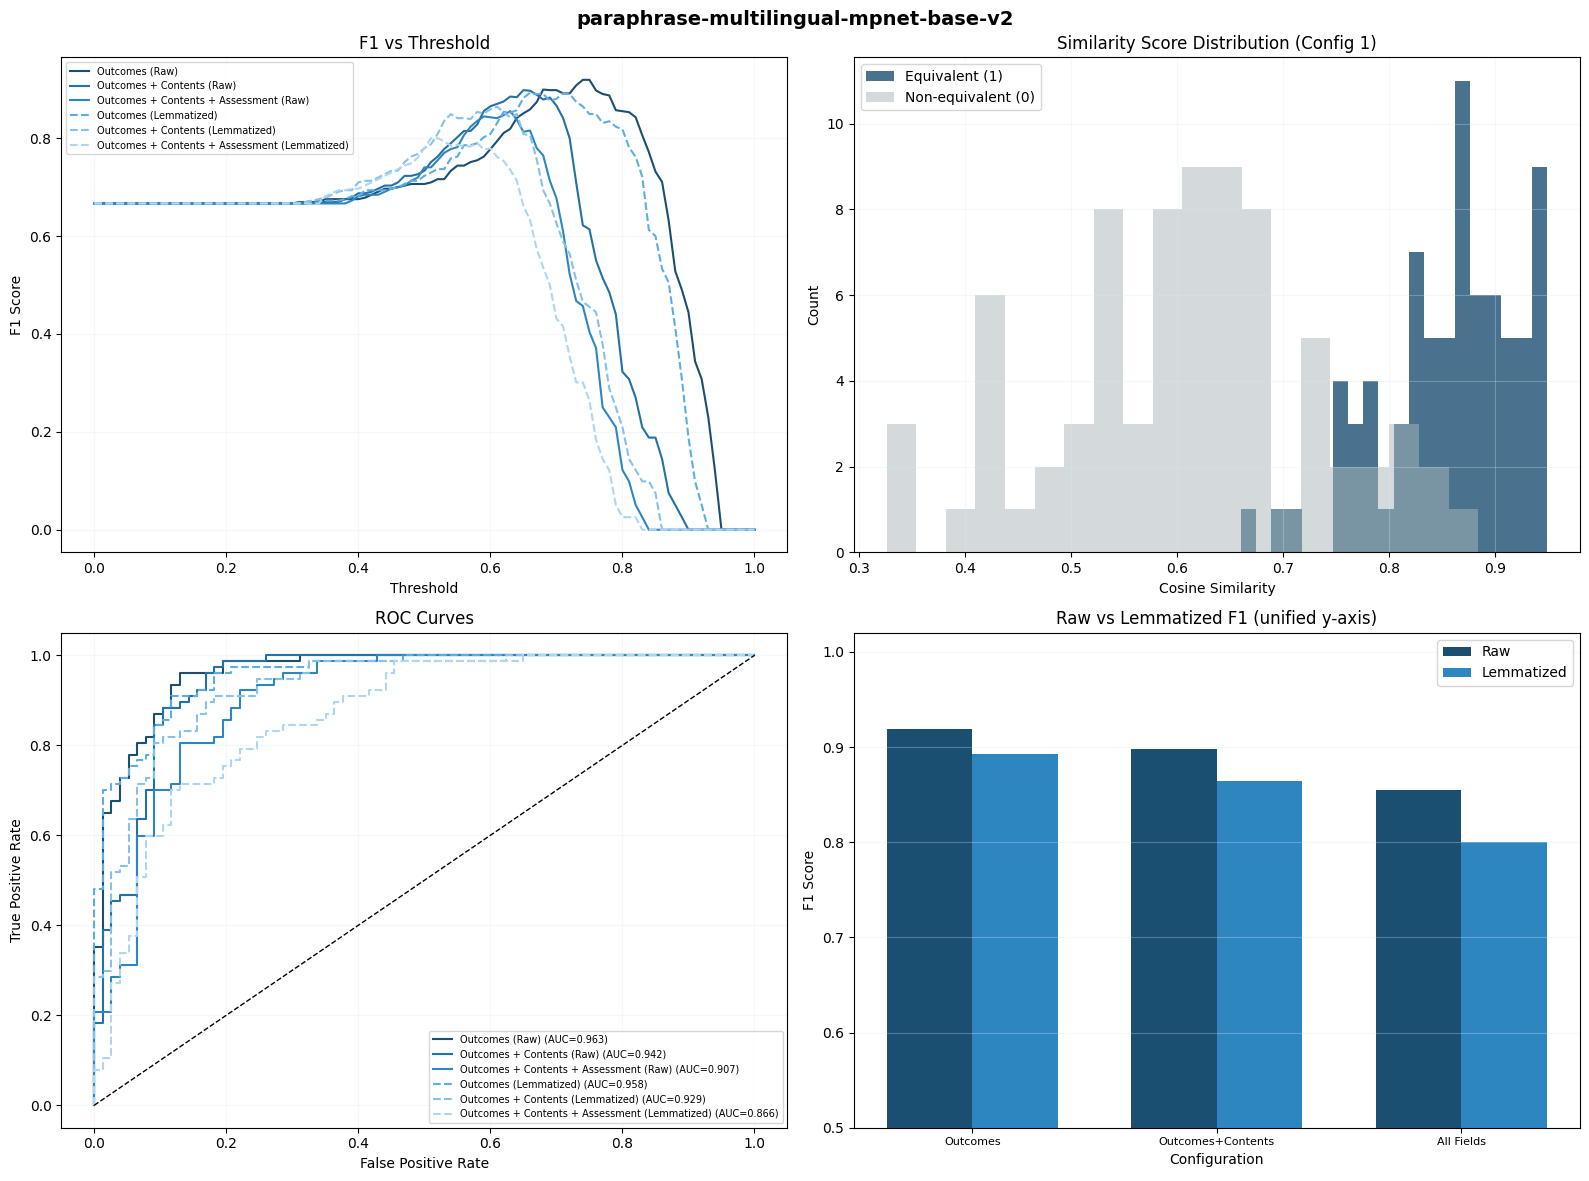

Plot saved: c:\Users\madee\OneDrive\Desktop\thesis\figures\main\mpnet_visualisations.png


In [9]:
plot_model_panel('mpnet', 'paraphrase-multilingual-mpnet-base-v2', 'mpnet_visualisations.png')

Worked best with raw learning outcomes only.

When more text was added, performance dropped, so extra course details seem to add noise rather than help.

Lemmatization also reduced the scores, which means the original raw wording was more useful for this model.

Overall, MPNet is usable, but not very stable across different text setups.

### Model 2: stsb-xlm-r-multilingual

This model is based on the XLM-RoBERTa architecture developed by Conneau et al. (2020) and fine-tuned on semantic textual similarity tasks using multilingual training data. XLM-RoBERTa was pre-trained on 2.5 terabytes of filtered CommonCrawl data covering 100 languages including Finnish, giving it a strong cross-lingual foundation. The stsb fine-tuning step explicitly optimises the model for sentence similarity tasks, making it a natural candidate for course description comparison. Like mpnet, it produces 768-dimensional sentence embeddings through the sentence-transformers library.

#### In-sample results: stsb-xlm-r-multilingual

In [10]:
show_model_results('stsb')

                                       config  best_threshold  precision  recall    f1  f1_ci_low  f1_ci_high  accuracy   auc
                               Outcomes (Raw)            0.88      0.906   1.000 0.951      0.913       0.981     0.948 0.988
                    Outcomes + Contents (Raw)            0.85      0.902   0.961 0.931      0.881       0.967     0.929 0.968
       Outcomes + Contents + Assessment (Raw)            0.83      0.924   0.948 0.936      0.894       0.971     0.935 0.971
                        Outcomes (Lemmatized)            0.83      0.874   0.987 0.927      0.882       0.965     0.922 0.981
             Outcomes + Contents (Lemmatized)            0.85      0.895   0.883 0.889      0.825       0.933     0.890 0.957
Outcomes + Contents + Assessment (Lemmatized)            0.79      0.847   0.935 0.889      0.832       0.934     0.883 0.953


#### Visualisations: stsb-xlm-r-multilingual

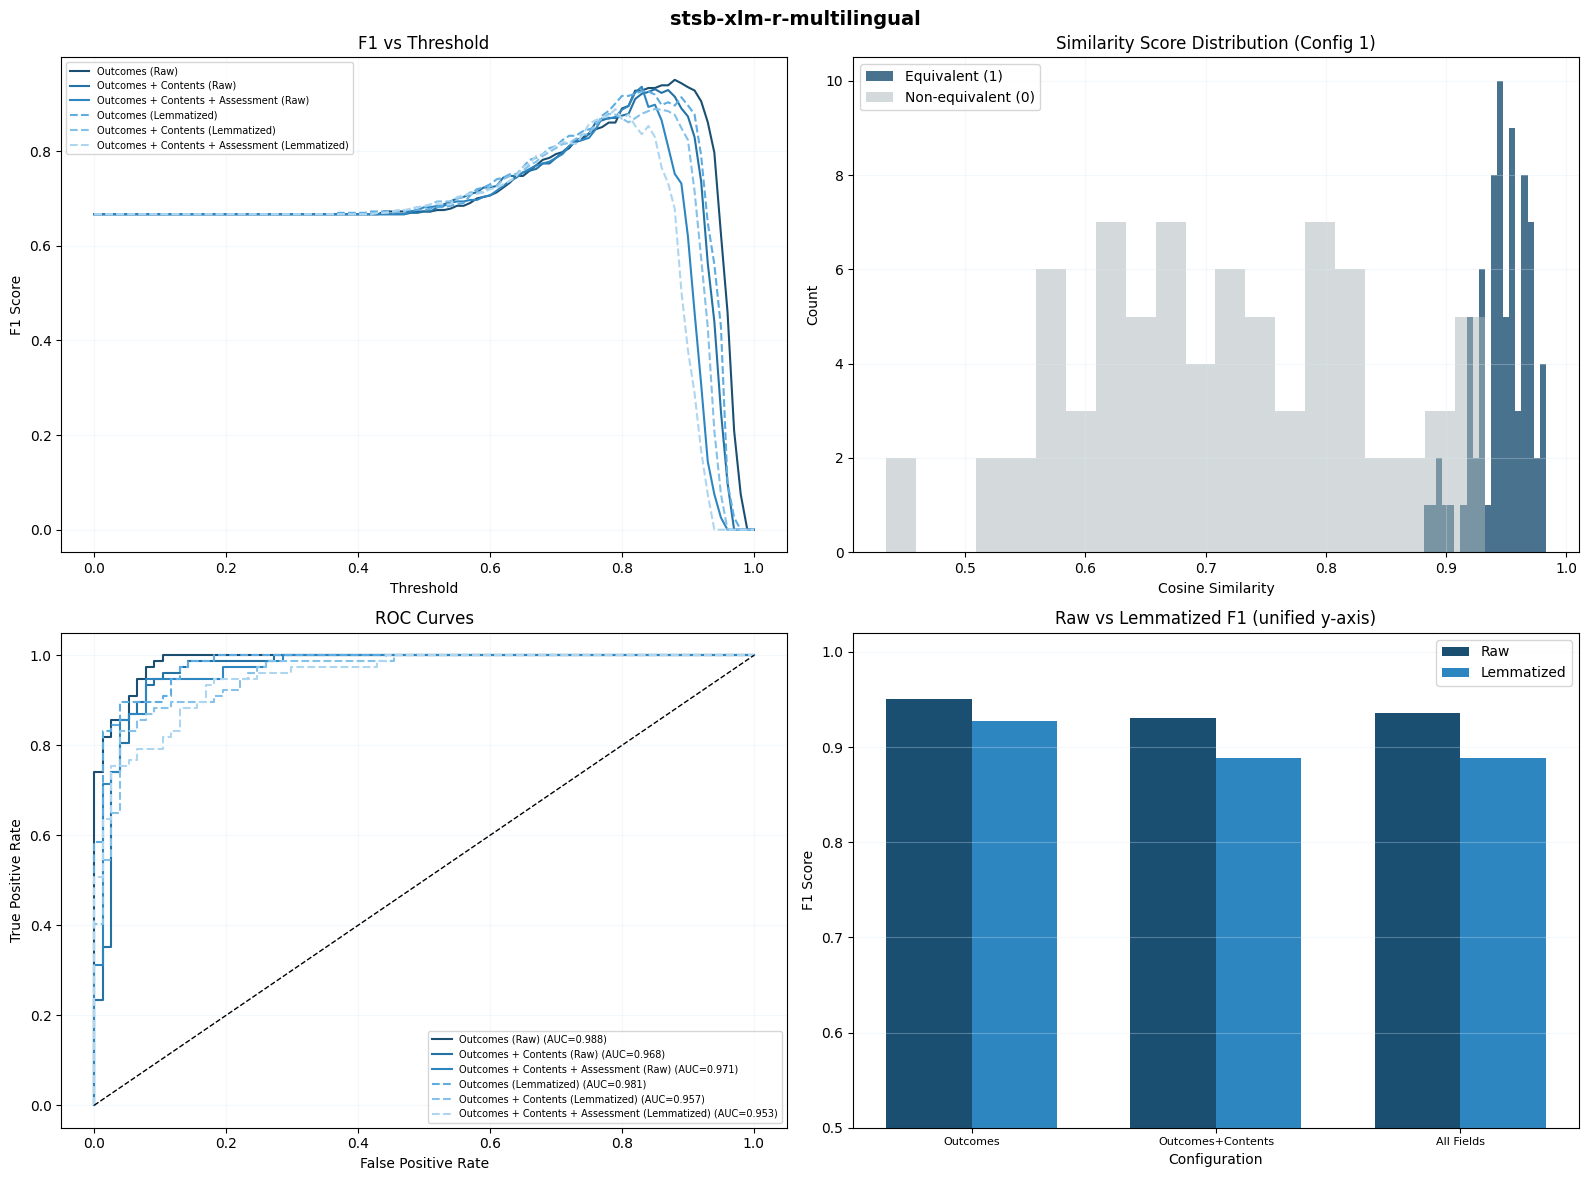

Plot saved: c:\Users\madee\OneDrive\Desktop\thesis\figures\main\stsb_visualisations.png


In [11]:
plot_model_panel('stsb', 'stsb-xlm-r-multilingual', 'stsb_visualisations.png')

This gave strong and consistent performance across all settings, with the best result from raw outcomes only.

The model separated similar and non-similar pairs clearly, which is why both F1 and AUC stayed high.

Raw text again worked better than lemmatized text, so preprocessing did not improve the results here.

Overall, STSB looks like a reliable model for bilingual course similarity.

### Model 3: intfloat/multilingual-e5-base

The multilingual E5 model was developed by Wang et al. (2024) and trained using weakly supervised contrastive learning on a large collection of multilingual text pairs. The base variant uses an XLM-RoBERTa backbone fine-tuned specifically for dense retrieval and semantic similarity tasks. A key design feature of E5 is its use of task prefixes during inference: the `query: ` prefix is applied to both sides for symmetric tasks such as semantic textual similarity, while `query: ` and `passage: ` are used for asymmetric retrieval. In this study both Finnish and English course descriptions receive the `query: ` prefix, following the model authors' recommendation for symmetric similarity as documented on the model card.

#### In-sample results: intfloat/multilingual-e5-base

In [12]:
show_model_results('e5')

                                       config  best_threshold  precision  recall    f1  f1_ci_low  f1_ci_high  accuracy   auc
                               Outcomes (Raw)            0.90      0.833   0.974 0.898      0.844       0.940     0.890 0.948
                    Outcomes + Contents (Raw)            0.91      0.884   0.987 0.933      0.888       0.967     0.929 0.964
       Outcomes + Contents + Assessment (Raw)            0.90      0.830   0.948 0.885      0.827       0.931     0.877 0.942
                        Outcomes (Lemmatized)            0.90      0.885   0.896 0.890      0.832       0.936     0.890 0.957
             Outcomes + Contents (Lemmatized)            0.90      0.890   0.948 0.918      0.866       0.959     0.916 0.957
Outcomes + Contents + Assessment (Lemmatized)            0.90      0.886   0.909 0.897      0.841       0.942     0.896 0.947


#### Visualisations: intfloat/multilingual-e5-base

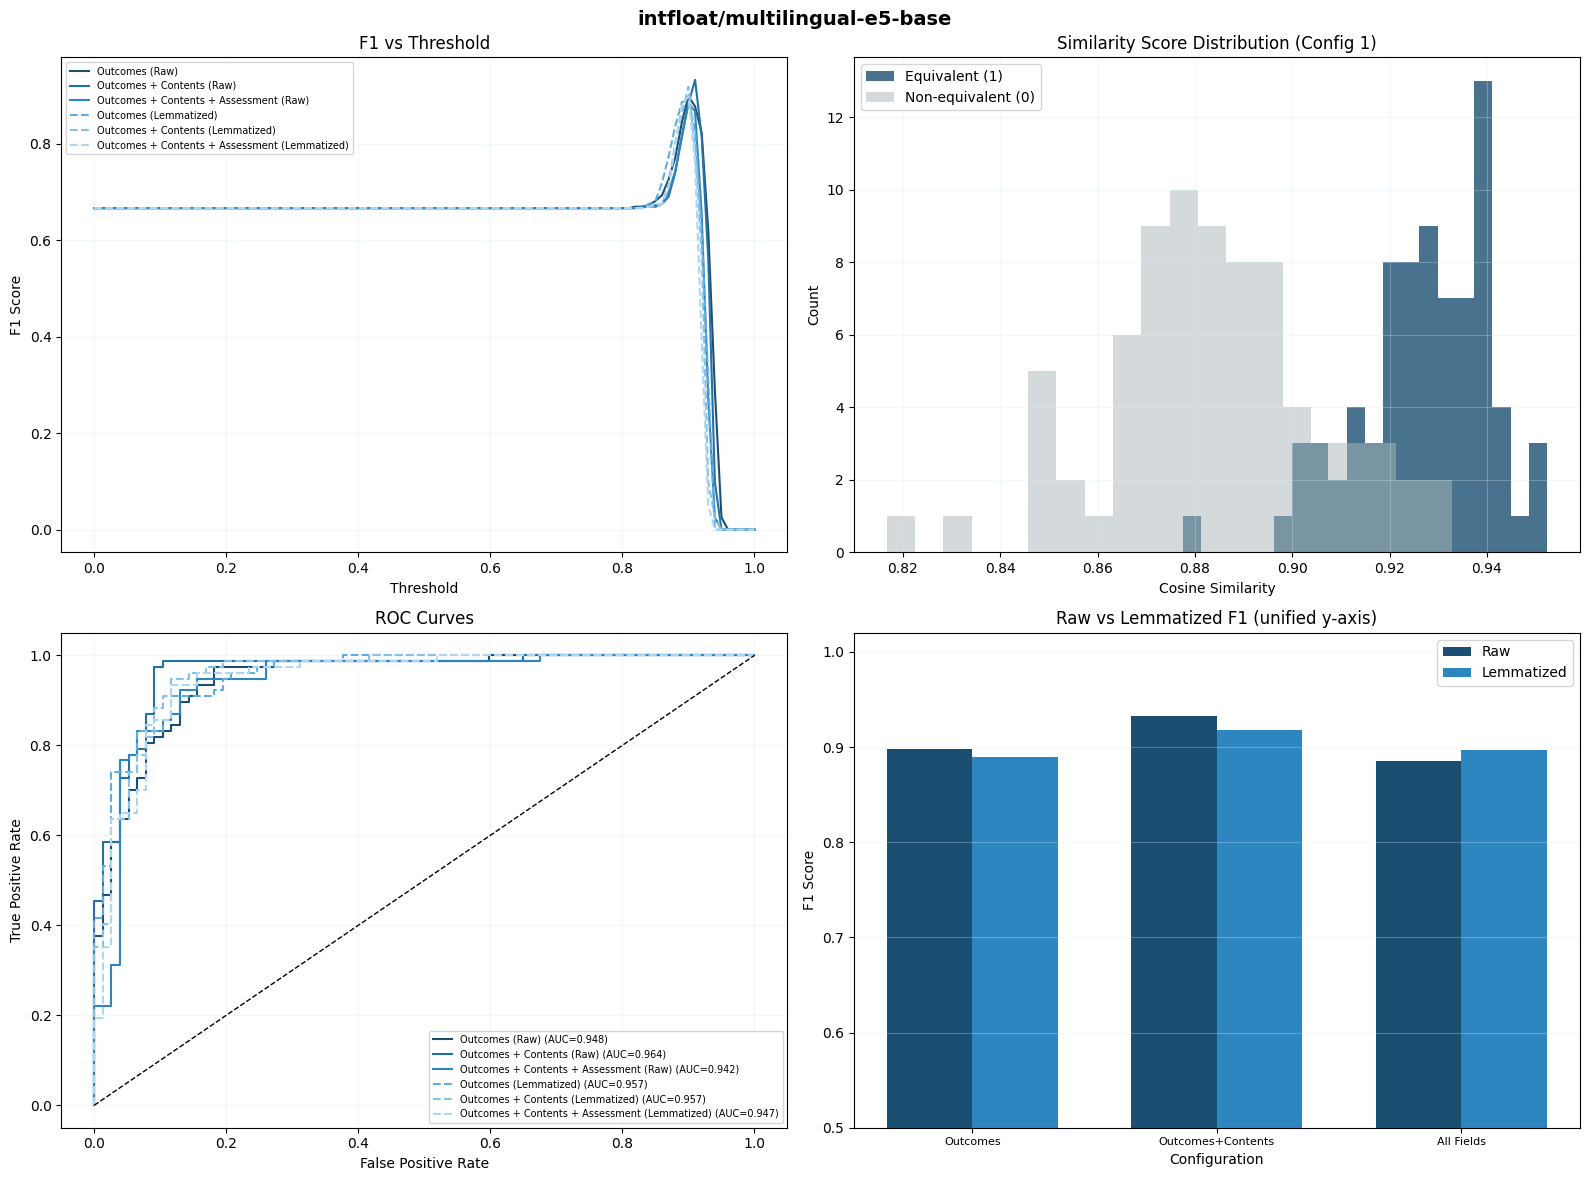

Plot saved: c:\Users\madee\OneDrive\Desktop\thesis\figures\main\e5_visualisations.png


In [13]:
plot_model_panel('e5', 'intfloat/multilingual-e5-base', 'e5_visualisations.png')

E5 performed well and quite steadily, with its best result from Outcomes + Contents (Raw).

This suggests the model benefits from a bit more context, but not from adding everything.

Lemmatization made only a small difference, so it did not clearly improve the model.

Overall, E5 is a strong middle option, but still not as convincing as the top models.

### Model 4: sentence-transformers/LaBSE

LaBSE, or Language-Agnostic BERT Sentence Embedding, was developed by Feng et al. (2022) and trained on 109 languages using a combination of masked language modelling and translation ranking objectives. Unlike the multilingual models adapted from English teachers through knowledge distillation, LaBSE was trained from scratch with cross-lingual alignment as its primary objective. This makes it architecturally distinct and particularly well suited for tasks where meaning must be matched across typologically different languages such as Finnish and English. LaBSE was added to the study after an exploratory comparison showed it outperforming the four initially selected models.

#### In-sample results: sentence-transformers/LaBSE

In [14]:
show_model_results('labse')

                                       config  best_threshold  precision  recall    f1  f1_ci_low  f1_ci_high  accuracy   auc
                               Outcomes (Raw)            0.87      0.963   1.000 0.981      0.955       1.000     0.981 0.999
                    Outcomes + Contents (Raw)            0.88      0.962   0.987 0.974      0.945       0.994     0.974 0.996
       Outcomes + Contents + Assessment (Raw)            0.84      0.939   1.000 0.969      0.940       0.993     0.968 0.992
                        Outcomes (Lemmatized)            0.85      0.939   1.000 0.969      0.938       0.994     0.968 0.997
             Outcomes + Contents (Lemmatized)            0.88      0.951   1.000 0.975      0.949       0.994     0.974 0.994
Outcomes + Contents + Assessment (Lemmatized)            0.89      0.950   0.987 0.968      0.938       0.993     0.968 0.998


#### Visualisations: sentence-transformers/LaBSE

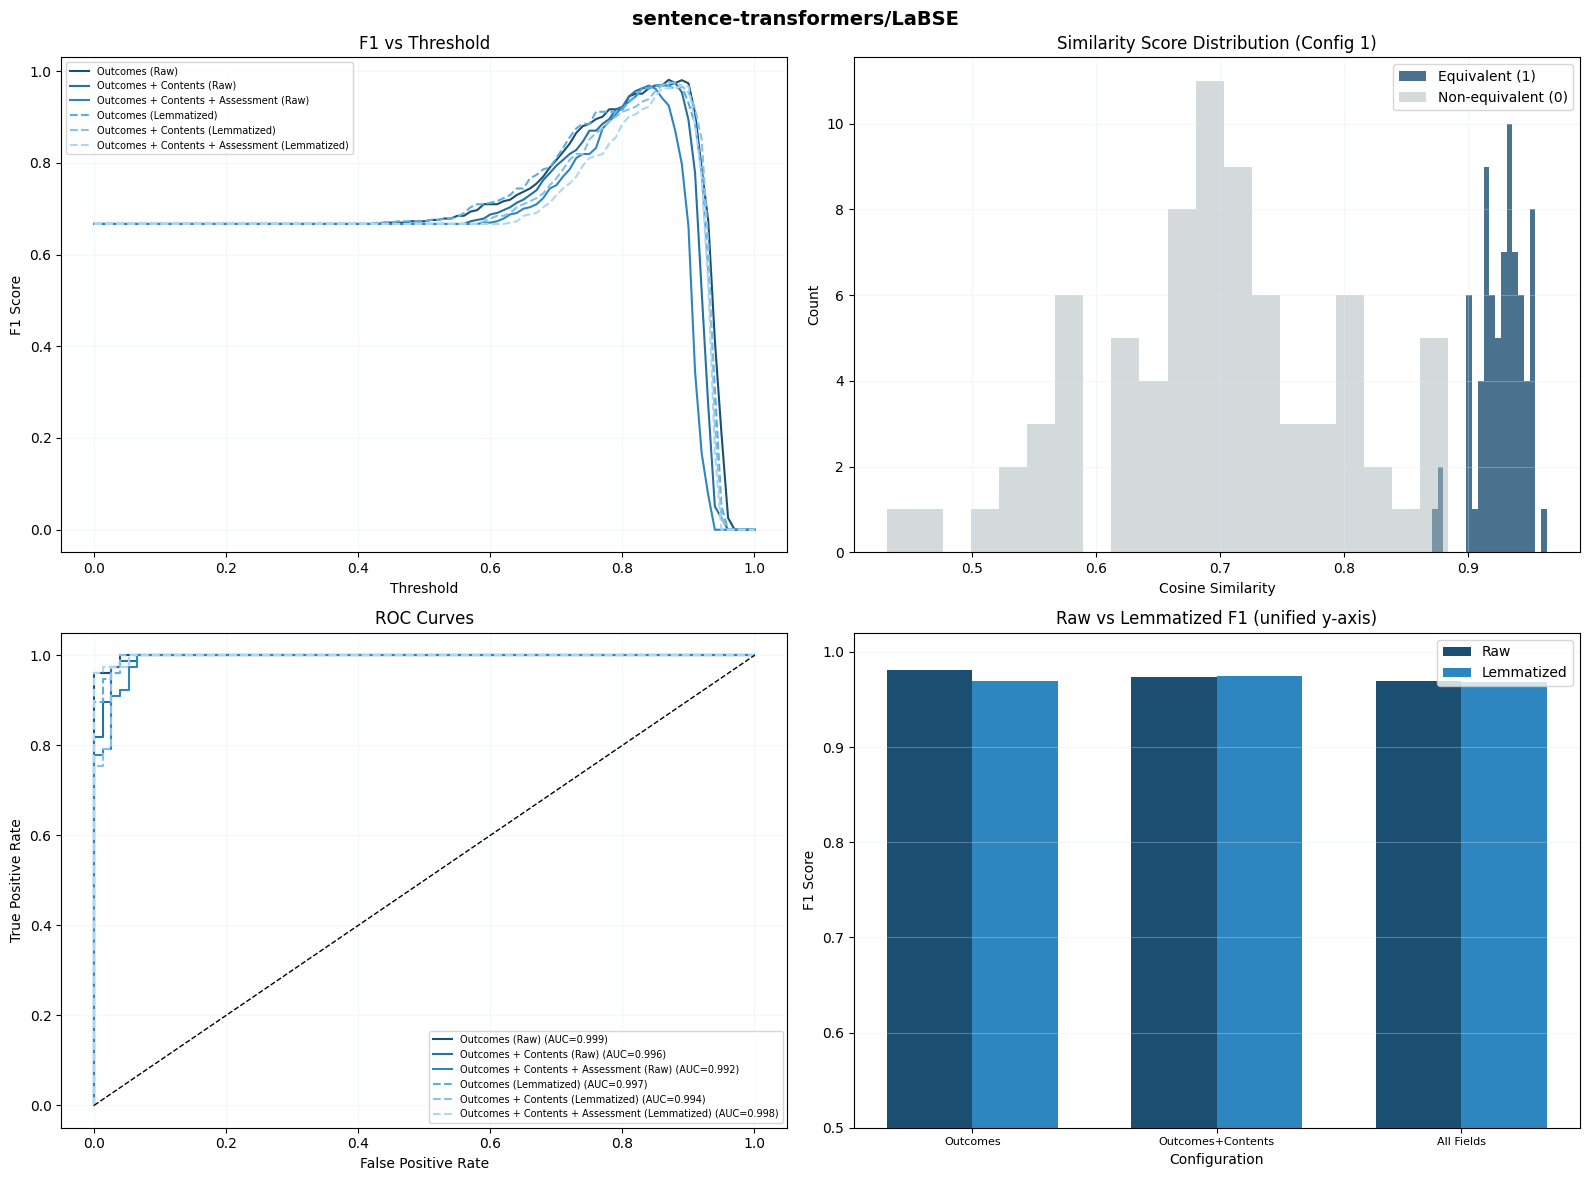

Plot saved: c:\Users\madee\OneDrive\Desktop\thesis\figures\main\labse_visualisations.png


In [15]:
plot_model_panel('labse', 'sentence-transformers/LaBSE', 'labse_visualisations.png')

LaBSE was the clear top performer in this study, with the highest and most stable scores across all text settings.

It separated similar and non-similar course pairs very cleanly, which explains its excellent F1 and near-perfect AUC values.

Unlike the other models, LaBSE stayed strong even when the text setup changed, so it was the most robust overall.

Raw and lemmatized text gave almost the same result, which shows LaBSE did not depend much on extra preprocessing.

### Model 5: TurkuNLP/bert-base-finnish-cased-v1

FinBERT is a monolingual BERT model trained exclusively on Finnish text by the TurkuNLP research group at the University of Turku (Virtanen et al., 2019). It represents the state of the art for Finnish monolingual NLP tasks. FinBERT is included here as a deliberate negative baseline: because it has never been trained on English text or cross-lingual alignment objectives, it is expected to struggle with Finnish-English similarity. This inclusion quantifies the performance gap between a language-specific monolingual model and the multilingual alternatives, providing a meaningful lower bound that contextualises the gains achieved by the multilingual models (Reimers and Gurevych, 2020).

#### In-sample results: TurkuNLP/bert-base-finnish-cased-v1

In [16]:
show_model_results('finbert')

                                       config  best_threshold  precision  recall    f1  f1_ci_low  f1_ci_high  accuracy   auc
                               Outcomes (Raw)            0.58      0.623   0.857 0.721      0.644       0.793     0.669 0.716
                    Outcomes + Contents (Raw)            0.56      0.571   0.935 0.709      0.633       0.773     0.617 0.697
       Outcomes + Contents + Assessment (Raw)            0.56      0.562   0.948 0.705      0.629       0.771     0.604 0.678
                        Outcomes (Lemmatized)            0.57      0.585   0.935 0.720      0.645       0.787     0.636 0.702
             Outcomes + Contents (Lemmatized)            0.55      0.551   0.974 0.704      0.636       0.767     0.591 0.701
Outcomes + Contents + Assessment (Lemmatized)            0.56      0.550   0.935 0.692      0.619       0.755     0.584 0.686


#### Visualisations: TurkuNLP/bert-base-finnish-cased-v1

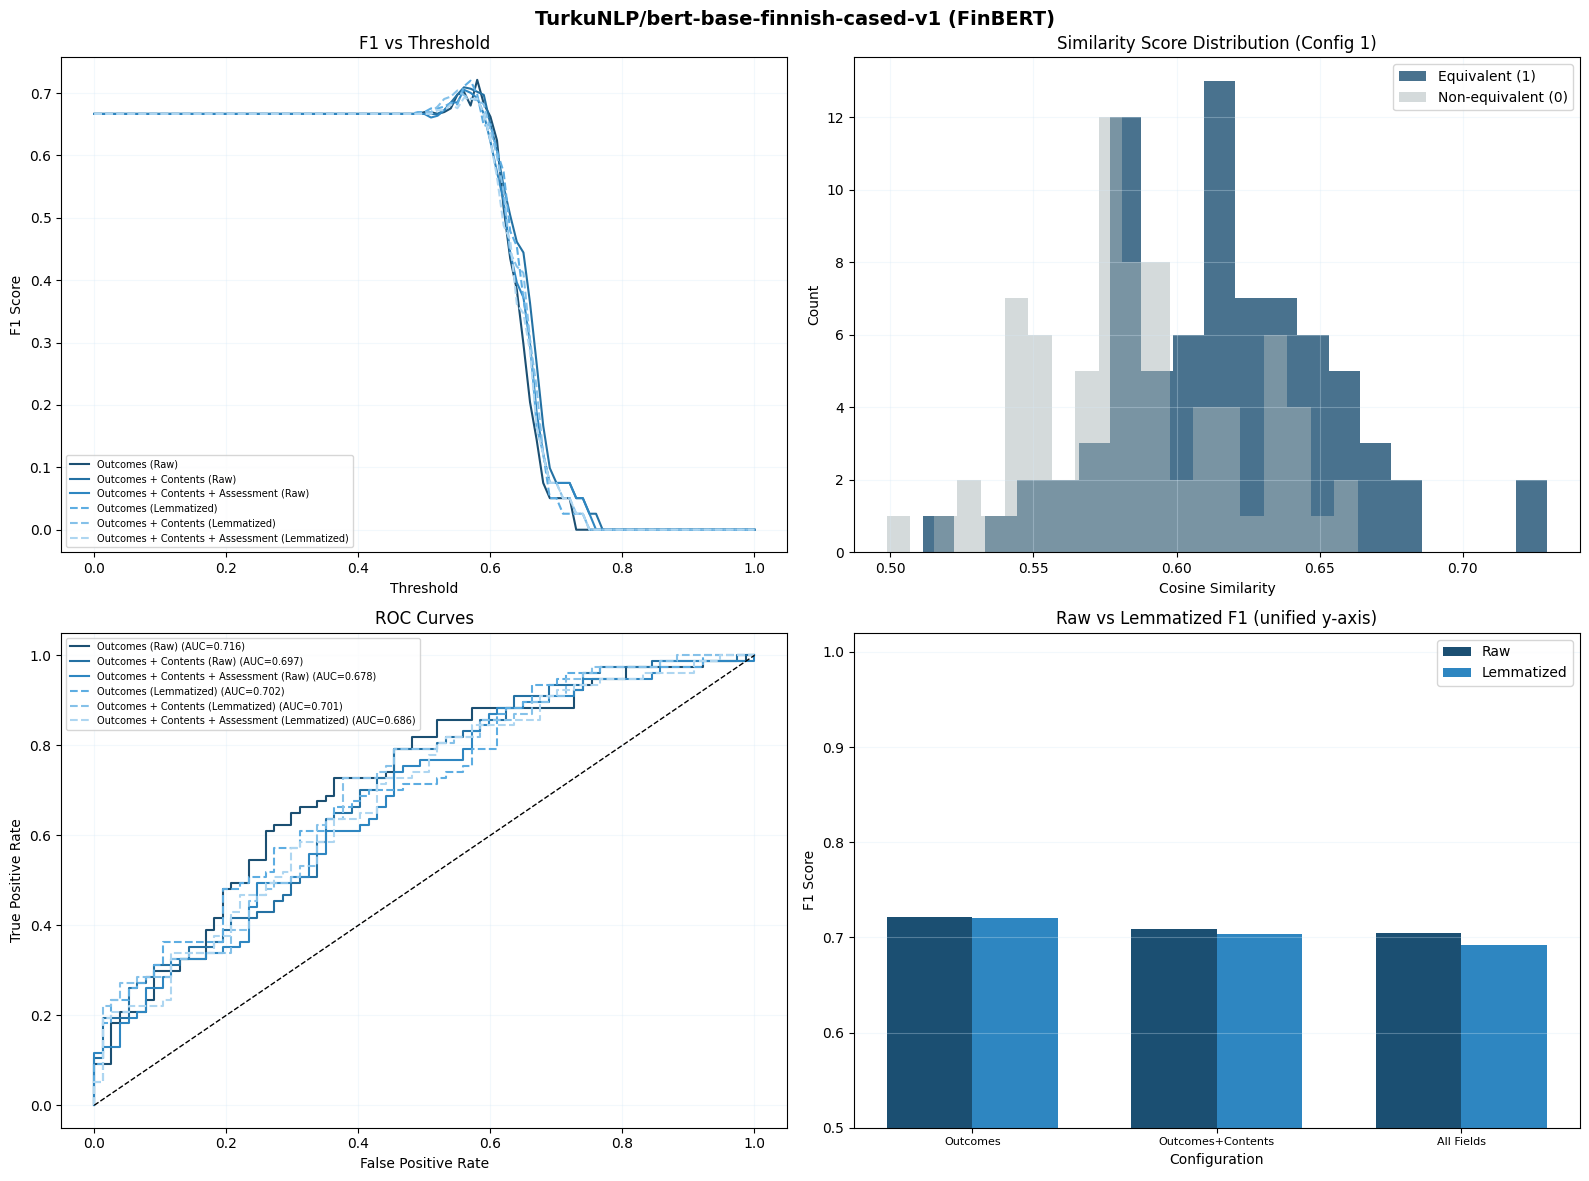

Plot saved: c:\Users\madee\OneDrive\Desktop\thesis\figures\main\finbert_visualisations.png


In [17]:
plot_model_panel('finbert', 'TurkuNLP/bert-base-finnish-cased-v1 (FinBERT)', 'finbert_visualisations.png')

FinBERT was the weakest model in the comparison, with clearly lower F1 and AUC than the multilingual models.

It caught many similar pairs, but its low precision shows that it also made many wrong matches.

Adding more text did not help, and lemmatization changed very little.

So FinBERT works mainly as a baseline, not as a strong choice for bilingual similarity.

## Cross-Model Comparison

The following visualisations bring together the results from all five models to directly address the central research questions. RQ1 and RQ2 are addressed by the heatmap and per-model best F1 chart, which compare models against each other on every configuration. RQ3 is addressed by the cross-model Raw versus Lemmatized panel. Threshold sensitivity across models (RQ4) is visible in the per-model F1 versus Threshold panels above.

### F1 Heatmap Across All Models and Configurations

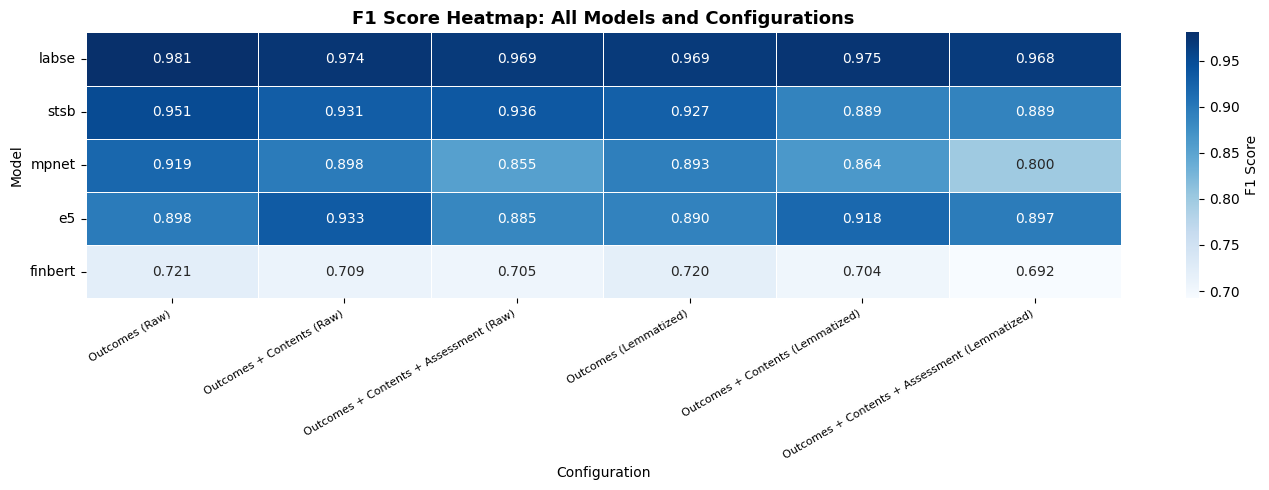

Plot saved: c:\Users\madee\OneDrive\Desktop\thesis\figures\main\heatmap_f1_all_models.png


In [18]:
heatmap_data = summary_df.pivot(index='model', columns='config', values='f1')

MODEL_ORDER = ['labse', 'stsb', 'mpnet', 'e5', 'finbert']
heatmap_data = heatmap_data.reindex(MODEL_ORDER)

config_order = list(config_names.values())
heatmap_data = heatmap_data[config_order]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    heatmap_data,
    annot=True, fmt='.3f',
    cmap='Blues', linewidths=0.5, linecolor='white',
    ax=ax, cbar_kws={'label': 'F1 Score'},
)
ax.set_title('F1 Score Heatmap: All Models and Configurations', fontsize=13, fontweight='bold')
ax.set_xlabel('Configuration')
ax.set_ylabel('Model')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plot_path = FIGURES_DIR / 'heatmap_f1_all_models.png'
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Plot saved: {plot_path}")

The heatmap reveals a clear performance hierarchy across all five models. LaBSE occupies the top row with the darkest blue shading across every configuration, while FinBERT sits at the bottom with much lighter shading, confirming its inability to perform cross-lingual comparison. The three middle models form a middle tier, with stsb consistently above mpnet and e5 trailing both. A pattern visible across all models except e5 is that raw configurations perform equally well or marginally better than their lemmatized counterparts, suggesting that lemmatization offers no systematic benefit for multilingual sentence embedding models on this task. The outcomes-only configuration performs competitively with longer configurations across all models, indicating that the learning outcomes field alone carries sufficient semantic information for reliable equivalence detection. The differences within each row are small, which is an important caveat and motivates the significance testing below.

### Best F1 per Model

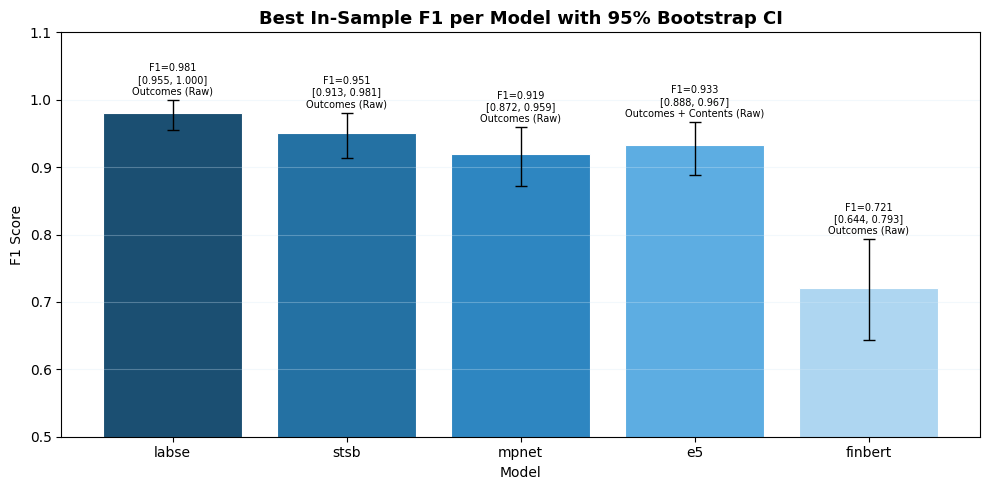

Plot saved: c:\Users\madee\OneDrive\Desktop\thesis\figures\main\best_f1_per_model.png


In [19]:
best_per_model = summary_df.loc[summary_df.groupby('model')['f1'].idxmax()].reset_index(drop=True)
best_per_model = best_per_model.set_index('model').reindex(MODEL_ORDER).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ['#1B4F72', '#2471A3', '#2E86C1', '#5DADE2', '#AED6F1']
bars = ax.bar(
    best_per_model['model'], best_per_model['f1'],
    color=bar_colors, edgecolor='white', linewidth=0.8,
)

# Error bars: CI half-widths
lower_err = best_per_model['f1'] - best_per_model['f1_ci_low']
upper_err = best_per_model['f1_ci_high'] - best_per_model['f1']
ax.errorbar(
    best_per_model['model'], best_per_model['f1'],
    yerr=[lower_err, upper_err],
    fmt='none', ecolor='black', capsize=4, linewidth=1,
)

for bar, row in zip(bars, best_per_model.itertuples()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        row.f1_ci_high + 0.005,
        f'F1={row.f1:.3f}\n[{row.f1_ci_low:.3f}, {row.f1_ci_high:.3f}]\n{row.config}',
        ha='center', va='bottom', fontsize=7,
    )

ax.set_title('Best In-Sample F1 per Model with 95% Bootstrap CI',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Model')
ax.set_ylabel('F1 Score')
ax.set_ylim(0.50, 1.10)
ax.grid(axis='y', alpha=0.3, color=GRID_COLOR)

plt.tight_layout()
plot_path = FIGURES_DIR / 'best_f1_per_model.png'
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Plot saved: {plot_path}")

The chart confirms the performance hierarchy and makes the uncertainty around each estimate visible for the first time. LaBSE achieves the highest in-sample F1 at around 0.98, followed by stsb, then mpnet, then e5, and FinBERT sits well below all multilingual models, separated by a gap of more than 0.20 F1 points. The 95 percent bootstrap confidence intervals for the top three models overlap visibly, which tempers any strong claim about strict model ordering among LaBSE, stsb, and mpnet. The gap between the multilingual models and FinBERT is far larger than any confidence interval, and therefore supports the qualitative conclusion that cross-lingual architecture is required for this task.

### AUC Score Comparison Across All Models and Configurations

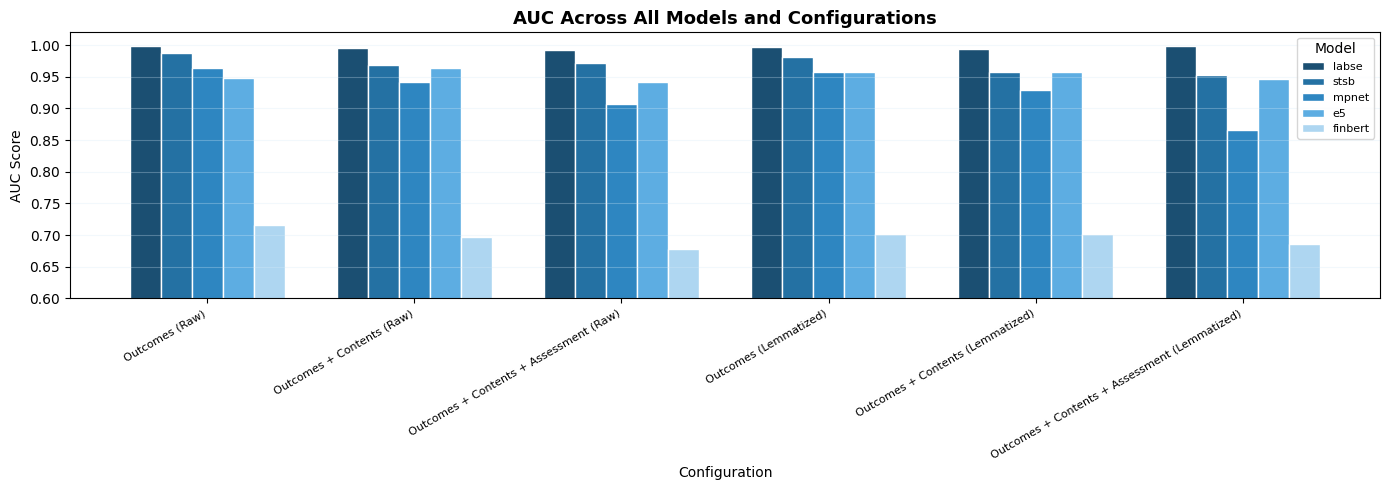

Plot saved: c:\Users\madee\OneDrive\Desktop\thesis\figures\main\auc_comparison_all_models.png


In [20]:
fig, ax = plt.subplots(figsize=(14, 5))

x = np.arange(len(config_names))
width = 0.15
offsets = [-2, -1, 0, 1, 2]
bar_colors = ['#1B4F72', '#2471A3', '#2E86C1', '#5DADE2', '#AED6F1']

for model_key, offset, color in zip(MODEL_ORDER, offsets, bar_colors):
    auc_values = [
        summary_df[(summary_df['model'] == model_key) &
                   (summary_df['config'] == config_names[c])]['auc'].values[0]
        for c in range(1, 7)
    ]
    ax.bar(x + offset * width, auc_values, width,
           label=model_key, color=color, edgecolor='white')

ax.set_title('AUC Across All Models and Configurations',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Configuration')
ax.set_ylabel('AUC Score')
ax.set_xticks(x)
ax.set_xticklabels(list(config_names.values()), rotation=30, ha='right', fontsize=8)
ax.legend(title='Model', fontsize=8)
ax.set_ylim(0.60, 1.02)
ax.grid(axis='y', alpha=0.3, color=GRID_COLOR)

plt.tight_layout()
plot_path = FIGURES_DIR / 'auc_comparison_all_models.png'
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Plot saved: {plot_path}")

The AUC comparison reinforces the F1 findings. The top three models, LaBSE, stsb, and mpnet, all achieve AUC values above 0.98 across every configuration, meaning their ability to rank equivalent pairs above non-equivalent pairs is near-perfect regardless of threshold. The e5 model sits at roughly 0.94 to 0.97, confirming that its compressed similarity score range reduces discriminative power even when threshold selection is removed from the equation. FinBERT stands clearly apart with AUC values between 0.68 and 0.72, only marginally above the 0.5 random baseline. The consistency of AUC scores across configurations within each model is notable: each multilingual model shows very little variation across the six configurations, suggesting that the choice of which fields to include matters less than the choice of which model to use, which is directly relevant to RQ2 and RQ3.

### Raw vs Lemmatized F1 Across All Models

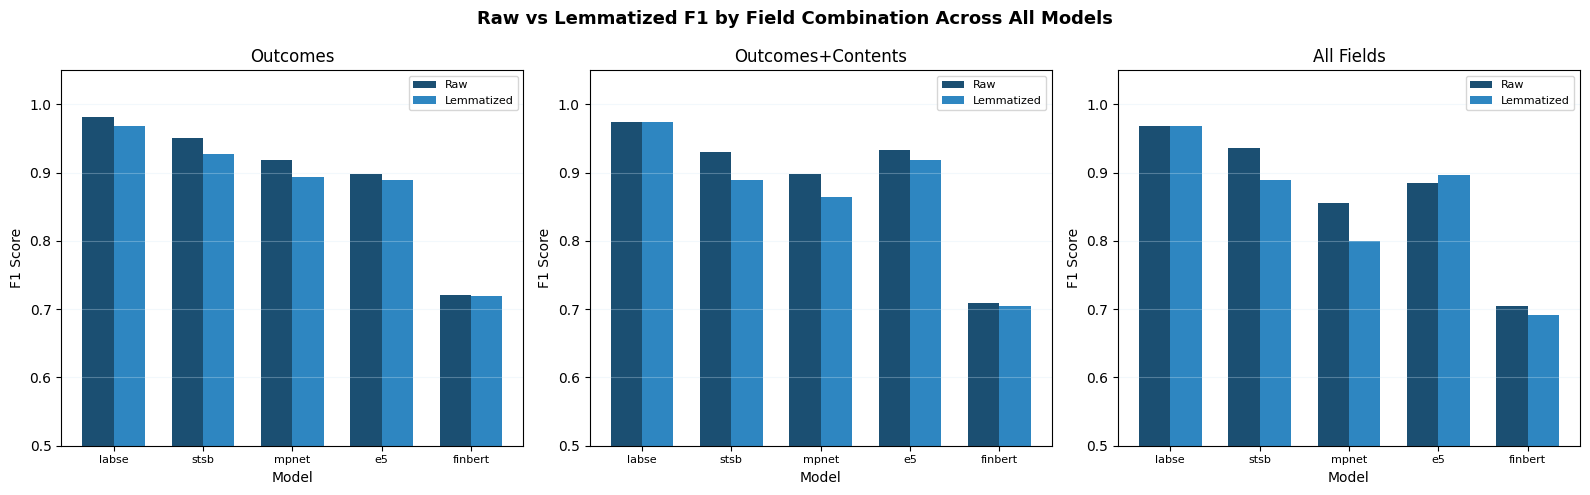

Plot saved: c:\Users\madee\OneDrive\Desktop\thesis\figures\main\raw_vs_lemmatized_all_models.png


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Raw vs Lemmatized F1 by Field Combination Across All Models',
             fontsize=13, fontweight='bold')

field_combos = ['Outcomes', 'Outcomes+Contents', 'All Fields']
raw_configs = [1, 2, 3]
lem_configs = [4, 5, 6]

for ax, raw_c, lem_c, combo in zip(axes, raw_configs, lem_configs, field_combos):
    raw_vals = [
        summary_df[(summary_df['model'] == m) &
                   (summary_df['config'] == config_names[raw_c])]['f1'].values[0]
        for m in MODEL_ORDER
    ]
    lem_vals = [
        summary_df[(summary_df['model'] == m) &
                   (summary_df['config'] == config_names[lem_c])]['f1'].values[0]
        for m in MODEL_ORDER
    ]

    x = np.arange(len(MODEL_ORDER))
    width = 0.35
    ax.bar(x - width/2, raw_vals, width, label='Raw', color=PRIMARY)
    ax.bar(x + width/2, lem_vals, width, label='Lemmatized', color=SECONDARY)
    ax.set_title(combo)
    ax.set_xlabel('Model')
    ax.set_ylabel('F1 Score')
    ax.set_xticks(x)
    ax.set_xticklabels(MODEL_ORDER, fontsize=8)
    ax.legend(fontsize=8)
    ax.set_ylim(0.50, 1.05)
    ax.grid(axis='y', alpha=0.3, color=GRID_COLOR)

plt.tight_layout()
plot_path = FIGURES_DIR / 'raw_vs_lemmatized_all_models.png'
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Plot saved: {plot_path}")

The three panels tell a consistent story across all field combinations. For LaBSE, stsb, and mpnet, raw and lemmatized bars are nearly identical in height, which answers RQ3 for the strongest models: lemmatization neither helps nor hurts in any meaningful way. The e5 model is the clear exception, with lemmatized text outperforming raw text across all three field combinations. This suggests that e5 benefits from reduced morphological variation in a way that the other multilingual models do not, possibly due to differences in training data composition or tokenization strategy. FinBERT shows no consistent direction, which is expected for a model that lacks the cross-lingual capacity to benefit reliably from any preprocessing strategy. The overall pattern supports the conclusion that preprocessing is a secondary factor compared to model selection, and that raw text is a sufficient and practical default for the three strongest models in this evaluation.

### Confusion Matrix for the Top Model

Below is the in-sample confusion matrix for the overall best combination, at the F1-maximizing threshold selected on the full 154 pairs. This gives the per-class error breakdown that the precision and recall numbers alone do not show: how many true equivalent pairs are missed, and how many non-equivalent pairs are incorrectly flagged as equivalent.

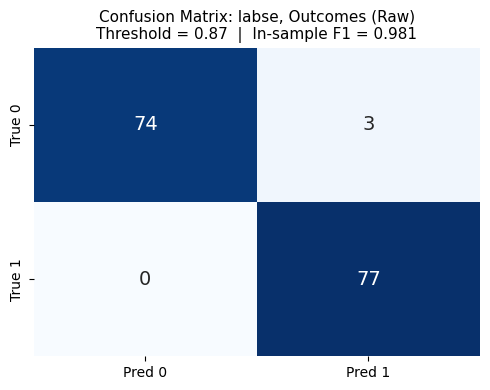

Plot saved: c:\Users\madee\OneDrive\Desktop\thesis\figures\main\confusion_matrix_top_model.png


In [22]:
# Pick the single best (model, config) by in-sample F1
top_row = summary_df.loc[summary_df['f1'].idxmax()]
top_model = top_row['model']
top_config_name = top_row['config']
top_config_num = [k for k, v in config_names.items() if v == top_config_name][0]
top_key = f'{top_model}_config{top_config_num}'
top_threshold = top_row['best_threshold']

sim_top = all_similarity_scores[top_key]
preds_top = (sim_top >= top_threshold).astype(int)
cm = confusion_matrix(labels, preds_top)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Pred 0', 'Pred 1'],
    yticklabels=['True 0', 'True 1'],
    ax=ax, cbar=False, annot_kws={'size': 14},
)
ax.set_title(
    f'Confusion Matrix: {top_model}, {top_config_name}\n'
    f'Threshold = {top_threshold:.2f}  |  In-sample F1 = {top_row["f1"]:.3f}',
    fontsize=11,
)
plt.tight_layout()
plot_path = FIGURES_DIR / 'confusion_matrix_top_model.png'
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Plot saved: {plot_path}")

The confusion matrix makes the specific error modes visible. The top model correctly classifies the large majority of both classes, with any remaining errors split across false positives (non-equivalent pairs classified as equivalent) and false negatives (equivalent pairs classified as non-equivalent). For curriculum mapping use cases, the false negative rate is typically the more important metric, because a missed equivalent pair leads to duplicate manual review, while a false positive is caught during human verification of flagged matches.

### Statistical Significance of Model Differences

The absolute F1 differences between the top multilingual models are small. To check whether these differences are statistically meaningful on a dataset of this size, McNemar's test is applied pairwise between the best configurations of the top four multilingual models. The test compares the paired pattern of correct and incorrect predictions between two classifiers on the same 154 pairs, and the exact binomial formulation is used because the discordant counts are small.

A p-value below 0.05 indicates that the two classifiers have statistically different error patterns at the conventional significance level. A p-value above 0.05 means the observed difference is compatible with chance given the sample size, and should be reported as such in the thesis.

In [23]:
# Get best-per-model predictions
def preds_for(model_key):
    row = summary_df[summary_df['model'] == model_key].loc[
        summary_df[summary_df['model'] == model_key]['f1'].idxmax()
    ]
    cfg_name = row['config']
    cfg_num = [k for k, v in config_names.items() if v == cfg_name][0]
    key = f'{model_key}_config{cfg_num}'
    t = row['best_threshold']
    sim = all_similarity_scores[key]
    return (sim >= t).astype(int), cfg_name, float(t)

models_to_compare = ['labse', 'stsb', 'mpnet', 'e5']
preds_cache = {m: preds_for(m) for m in models_to_compare}

mcnemar_rows = []
for i in range(len(models_to_compare)):
    for j in range(i + 1, len(models_to_compare)):
        a, b = models_to_compare[i], models_to_compare[j]
        p_a, cfg_a, t_a = preds_cache[a]
        p_b, cfg_b, t_b = preds_cache[b]
        pval, n_a_only, n_b_only = mcnemar_exact(p_a, p_b, labels)
        mcnemar_rows.append({
            'model_a'           : a,
            'config_a'          : cfg_a,
            'model_b'           : b,
            'config_b'          : cfg_b,
            'a_only_correct'    : n_a_only,
            'b_only_correct'    : n_b_only,
            'p_value'           : round(pval, 4),
            'significant_at_005': pval < 0.05,
        })

mcnemar_df = pd.DataFrame(mcnemar_rows)
mcnemar_df.to_csv(SUMMARY_DIR / 'mcnemar_pairwise.csv', index=False)
print("Pairwise McNemar's test on best-per-model predictions:\n")
print(mcnemar_df.to_string(index=False))

Pairwise McNemar's test on best-per-model predictions:

model_a       config_a model_b                  config_b  a_only_correct  b_only_correct  p_value  significant_at_005
  labse Outcomes (Raw)    stsb            Outcomes (Raw)               5               0   0.0625               False
  labse Outcomes (Raw)   mpnet            Outcomes (Raw)              11               1   0.0063                True
  labse Outcomes (Raw)      e5 Outcomes + Contents (Raw)               8               0   0.0078                True
   stsb Outcomes (Raw)   mpnet            Outcomes (Raw)               9               4   0.2668               False
   stsb Outcomes (Raw)      e5 Outcomes + Contents (Raw)               6               3   0.5078               False
  mpnet Outcomes (Raw)      e5 Outcomes + Contents (Raw)               2               4   0.6875               False


Each row reports how many pairs one model classified correctly while the other did not, along with the exact binomial p-value for the null hypothesis that both models have the same error rate. Rows where `significant_at_005` is True correspond to comparisons where the F1 difference is unlikely to be due to chance on this dataset. Rows where it is False indicate that, despite a visible gap in headline F1, the paired-error evidence is compatible with no true difference at this sample size. These p-values are the correct evidence to cite in the thesis when discussing the ordering of the top multilingual models.

## Part 2: Stratified 5-Fold Cross-Validation

Part 1 selected the threshold that maximizes F1 on the same 154 pairs on which F1 was then reported, which biases the estimates upward. Part 2 addresses this directly using stratified 5-fold cross-validation: in each fold, the threshold is selected on the four training folds only and F1 is then evaluated on the held-out fold. The final numbers reported per model-configuration pair are the mean and standard deviation of F1 across the five held-out folds.

Stratification preserves the 50/50 label balance in every fold. With 154 pairs split into 5 folds, each held-out fold contains approximately 31 pairs, which is small. This is why the standard deviation across folds is as important as the mean: a model whose F1 is stable across all five folds can be trusted in a way that a model whose F1 swings widely cannot, regardless of which fold average is higher.

In [24]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
# Pre-compute the fold indices once so all combinations use the same splits
fold_splits = list(skf.split(np.zeros(len(labels)), labels))
for i, (tr, te) in enumerate(fold_splits):
    pos = int(labels[te].sum())
    neg = int((labels[te] == 0).sum())
    print(f"Fold {i+1}: train={len(tr)}, test={len(te)} (pos={pos}, neg={neg})")

Fold 1: train=123, test=31 (pos=16, neg=15)
Fold 2: train=123, test=31 (pos=16, neg=15)
Fold 3: train=123, test=31 (pos=15, neg=16)
Fold 4: train=123, test=31 (pos=15, neg=16)
Fold 5: train=124, test=30 (pos=15, neg=15)


In [25]:
cv_rows = []

for model_key in model_keys:
    for config_num in configs:
        sim = all_similarity_scores[f'{model_key}_config{config_num}']

        fold_f1, fold_p, fold_r, fold_acc, fold_auc, fold_thresh = [], [], [], [], [], []

        for train_idx, test_idx in fold_splits:
            y_tr, y_te = labels[train_idx], labels[test_idx]
            s_tr, s_te = sim[train_idx], sim[test_idx]

            # Select threshold on training fold only
            train_sweep = threshold_sweep(s_tr, y_tr, thresholds)
            t_best_fold, _ = best_threshold(train_sweep)

            # Evaluate on held-out fold
            preds_te = (s_te >= t_best_fold).astype(int)
            fold_f1.append(f1_score(y_te, preds_te, zero_division=0))
            fold_p.append(precision_score(y_te, preds_te, zero_division=0))
            fold_r.append(recall_score(y_te, preds_te, zero_division=0))
            fold_acc.append(accuracy_score(y_te, preds_te))
            fold_auc.append(roc_auc_score(y_te, s_te))
            fold_thresh.append(t_best_fold)

        full_f1 = summary_df[
            (summary_df['model'] == model_key) &
            (summary_df['config'] == config_names[config_num])
        ]['f1'].values[0]

        cv_rows.append({
            'model'          : model_key,
            'config'         : config_names[config_num],
            'cv_f1_mean'     : round(float(np.mean(fold_f1)), 3),
            'cv_f1_std'      : round(float(np.std(fold_f1, ddof=1)), 3),
            'cv_f1_min'      : round(float(np.min(fold_f1)), 3),
            'cv_f1_max'      : round(float(np.max(fold_f1)), 3),
            'cv_precision'   : round(float(np.mean(fold_p)), 3),
            'cv_recall'      : round(float(np.mean(fold_r)), 3),
            'cv_accuracy'    : round(float(np.mean(fold_acc)), 3),
            'cv_auc'         : round(float(np.mean(fold_auc)), 3),
            'threshold_mean' : round(float(np.mean(fold_thresh)), 3),
            'threshold_std'  : round(float(np.std(fold_thresh, ddof=1)), 3),
            'full_f1_insamp' : round(float(full_f1), 3),
            'optimism_gap'   : round(float(full_f1) - float(np.mean(fold_f1)), 3),
        })

cv_df = pd.DataFrame(cv_rows)
cv_df.to_csv(SUMMARY_DIR / 'cv_5fold_results.csv', index=False)
print("5-fold stratified CV results:\n")
print(cv_df.to_string(index=False))

5-fold stratified CV results:

  model                                        config  cv_f1_mean  cv_f1_std  cv_f1_min  cv_f1_max  cv_precision  cv_recall  cv_accuracy  cv_auc  threshold_mean  threshold_std  full_f1_insamp  optimism_gap
  mpnet                                Outcomes (Raw)       0.920      0.051      0.875      1.000         0.884      0.961        0.916   0.964           0.745          0.000           0.919        -0.001
  mpnet                     Outcomes + Contents (Raw)       0.865      0.093      0.774      1.000         0.811      0.937        0.852   0.938           0.654          0.022           0.898         0.033
  mpnet        Outcomes + Contents + Assessment (Raw)       0.830      0.120      0.710      1.000         0.795      0.885        0.813   0.902           0.630          0.007           0.855         0.025
  mpnet                         Outcomes (Lemmatized)       0.875      0.030      0.839      0.903         0.847      0.910        0.870   0.958 

In [26]:
# Top CV combinations, ordered by mean F1
top_cv = cv_df.sort_values('cv_f1_mean', ascending=False).head(10)
print("Top 10 combinations by cross-validated mean F1:\n")
print(top_cv.to_string(index=False))

Top 10 combinations by cross-validated mean F1:

model                                        config  cv_f1_mean  cv_f1_std  cv_f1_min  cv_f1_max  cv_precision  cv_recall  cv_accuracy  cv_auc  threshold_mean  threshold_std  full_f1_insamp  optimism_gap
labse              Outcomes + Contents (Lemmatized)       0.976      0.033      0.938      1.000         0.954      1.000        0.974   0.992           0.874          0.002           0.975        -0.001
labse        Outcomes + Contents + Assessment (Raw)       0.970      0.030      0.938      1.000         0.942      1.000        0.968   0.992           0.839          0.002           0.969        -0.001
labse                     Outcomes + Contents (Raw)       0.969      0.043      0.909      1.000         0.954      0.988        0.968   0.995           0.876          0.009           0.974         0.005
labse                                Outcomes (Raw)       0.968      0.022      0.938      1.000         0.965      0.974        0.968 

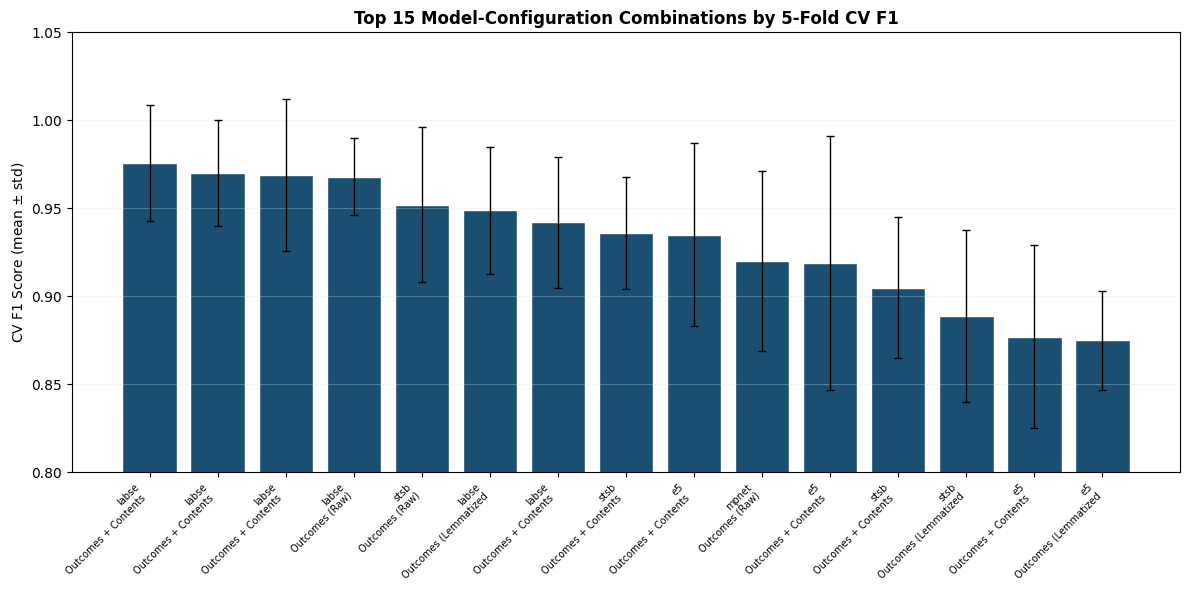

Plot saved: c:\Users\madee\OneDrive\Desktop\thesis\figures\main\cv_top_combinations.png


In [27]:
# Visualize CV mean with error bars
fig, ax = plt.subplots(figsize=(12, 6))

cv_sorted = cv_df.sort_values('cv_f1_mean', ascending=False).reset_index(drop=True).head(15)
x = np.arange(len(cv_sorted))
ax.bar(x, cv_sorted['cv_f1_mean'],
       yerr=cv_sorted['cv_f1_std'],
       color=PRIMARY, edgecolor='white',
       error_kw={'ecolor': 'black', 'capsize': 3, 'linewidth': 1})

labels_short = [f"{r.model}\n{r.config[:20]}" for r in cv_sorted.itertuples()]
ax.set_xticks(x)
ax.set_xticklabels(labels_short, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('CV F1 Score (mean $\\pm$ std)')
ax.set_title('Top 15 Model-Configuration Combinations by 5-Fold CV F1',
             fontsize=12, fontweight='bold')
ax.set_ylim(0.80, 1.05)
ax.grid(axis='y', alpha=0.3, color=GRID_COLOR)

plt.tight_layout()
plot_path = FIGURES_DIR / 'cv_top_combinations.png'
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Plot saved: {plot_path}")

The cross-validated ranking confirms the in-sample hierarchy: LaBSE configurations dominate the top of the table, followed by stsb and mpnet configurations. The cross-validated F1 means are slightly below the in-sample F1 values, which is the expected consequence of removing the threshold-selection optimism. The standard deviations give a concrete sense of fold-to-fold variability, and in most cases they are smaller than the gaps between adjacent models in the ranking. With only 31 pairs per held-out fold, some variability is inevitable and the fold-to-fold spread should be read as a natural feature of small-sample evaluation rather than as evidence of model instability.

### Notebook Summary

This notebook evaluated all 30 model-configuration combinations using cosine similarity and threshold-based binary classification, and validated the findings through 5-fold stratified cross-validation and pairwise McNemar's testing.

Part 1 produced in-sample F1 values with bootstrap 95 percent confidence intervals. LaBSE achieved the highest in-sample F1, followed by stsb, mpnet, e5, and FinBERT. The ordering among the top three multilingual models is visible but the confidence intervals overlap, which means strong claims about strict model ordering between LaBSE, stsb, and mpnet need to be made carefully.

Part 2 cross-validated these findings. The cross-validated ranking preserves the in-sample hierarchy, and the optimism gap between in-sample and cross-validated F1 is small for the top models, confirming that the Part 1 results are not primarily an artifact of threshold selection.

Pairwise McNemar's testing addresses the question of statistical significance directly. The thesis should quote these p-values when discussing model ordering, rather than relying on raw F1 gaps alone.

All results and figures have been saved under `data/results/` and `figures/main/`, and are ready for the extended analysis in Notebook 5. Three specific limitations should be carried into the methodology chapter: the 31-pair held-out folds are small and contribute to the observed standard deviations, the constructed negative pairs introduce non-independence with real pairs, and the 512-token truncation documented in Notebook 2 affects a subset of configurations.